In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import ViT
from pathlib import Path


In [3]:
# 设置路径，与 Lab1 的 notebook 保持类似写法
root = Path('/home/gracchus/code/UCAS-Deep-Learning-2026Spring')
lab2_dir = root / 'Lab2'
figure_dir = lab2_dir / 'Figure'
figure_dir.mkdir(exist_ok=True)

log_path = lab2_dir / 'logs/train_log.csv'
log_df = pd.read_csv(log_path)
log_df.head()


,epoch,train_loss,val_loss,val_acc,test_loss,test_acc,lr
0,1,1.998052,2.207528,0.2036,2.207190,0.2009,0.000112
1,2,1.861573,2.122296,0.2348,2.119922,0.2370,0.000144
2,3,1.769140,2.054916,0.2608,2.050183,0.2689,0.000176
3,4,1.692509,2.002498,0.2810,1.994653,0.2917,0.000208
4,5,1.676509,1.958326,0.3020,1.948265,0.3167,0.000240


In [4]:
# 统计最优验证集准确率、最优测试集准确率和最终结果
best_val = log_df.loc[log_df['val_acc'].idxmax()]
best_test = log_df.loc[log_df['test_acc'].idxmax()]
final = log_df.iloc[-1]

print(f"best val_acc: epoch={int(best_val['epoch'])}, value={best_val['val_acc']:.4%}, test_acc={best_val['test_acc']:.4%}")
print(f"best test_acc: epoch={int(best_test['epoch'])}, value={best_test['test_acc']:.4%}, val_acc={best_test['val_acc']:.4%}")
print(f"final test_acc: epoch={int(final['epoch'])}, value={final['test_acc']:.4%}")


best val_acc: epoch=136, value=85.6800%, test_acc=85.6100%
best test_acc: epoch=131, value=85.7900%, val_acc=85.4600%
final test_acc: epoch=176, value=85.5700%


In [5]:
# 查看模型规模，便于报告中引用
model = ViT.ViT()
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"total parameters: {total_params:,}")
print(f"trainable parameters: {trainable_params:,}")


total parameters: 559,370
trainable parameters: 559,370


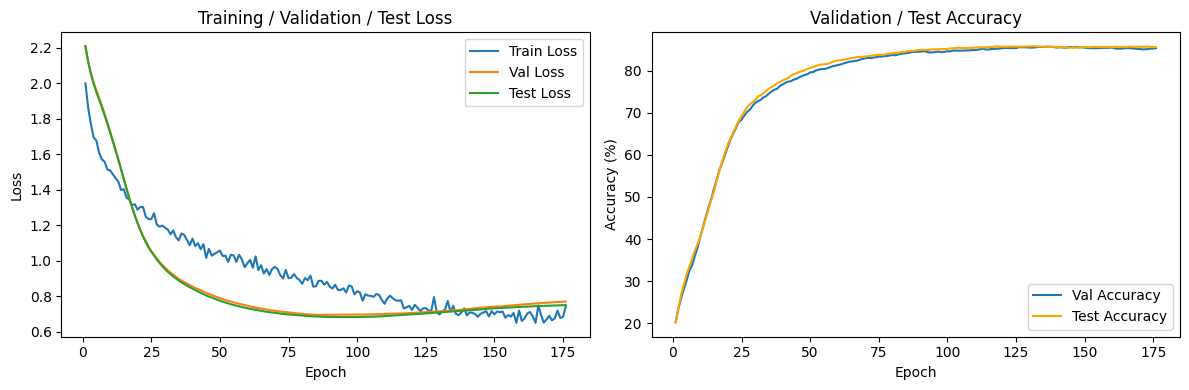

In [7]:
# 读取训练日志csv文件，绘制训练损失和测试准确率的变化曲线
plt.style.use('default')

plt.figure(figsize=(12, 4))

# 训练、验证、测试损失
plt.subplot(1, 2, 1)
plt.plot(log_df['epoch'], log_df['train_loss'], label='Train Loss')
plt.plot(log_df['epoch'], log_df['val_loss'], label='Val Loss')
plt.plot(log_df['epoch'], log_df['test_loss'], label='Test Loss')
plt.xticks(np.arange(0, int(log_df['epoch'].max()) + 1, 25))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training / Validation / Test Loss')
plt.legend()

# 验证集和测试集准确率（百分比）
plt.subplot(1, 2, 2)
plt.plot(log_df['epoch'], log_df['val_acc'] * 100, label='Val Accuracy')
plt.plot(log_df['epoch'], log_df['test_acc'] * 100, label='Test Accuracy', color='orange')
plt.xticks(np.arange(0, int(log_df['epoch'].max()) + 1, 25))
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation / Test Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(figure_dir / 'loss_acc_curves.png', bbox_inches='tight', dpi=300)
plt.show()


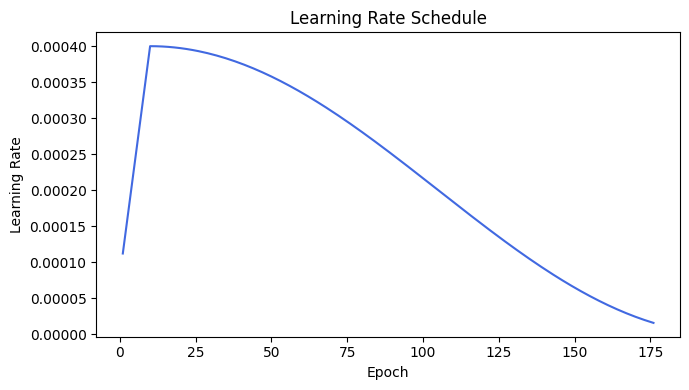

In [8]:
# 绘制学习率调度曲线
plt.figure(figsize=(7, 4))
plt.plot(log_df['epoch'], log_df['lr'], color='royalblue')
plt.xticks(np.arange(0, int(log_df['epoch'].max()) + 1, 25))
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule')
plt.tight_layout()
plt.savefig(figure_dir / 'lr_curve.png', bbox_inches='tight', dpi=300)
plt.show()


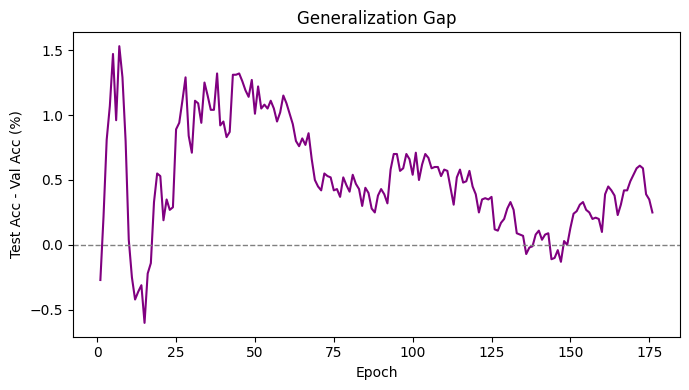

In [9]:
# 绘制测试集准确率与验证集准确率的差距，观察泛化情况
log_df['test_val_gap'] = (log_df['test_acc'] - log_df['val_acc']) * 100

plt.figure(figsize=(7, 4))
plt.plot(log_df['epoch'], log_df['test_val_gap'], color='purple')
plt.axhline(0, color='gray', linewidth=1, linestyle='--')
plt.xticks(np.arange(0, int(log_df['epoch'].max()) + 1, 25))
plt.xlabel('Epoch')
plt.ylabel('Test Acc - Val Acc (%)')
plt.title('Generalization Gap')
plt.tight_layout()
plt.savefig(figure_dir / 'generalization_gap.png', bbox_inches='tight', dpi=300)
plt.show()


/tmp/ipykernel_10151/1433911044.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(data=metrics, x='metric', y='accuracy', palette=['#f59e0b', '#16a34a', '#2563eb', '#64748b'])


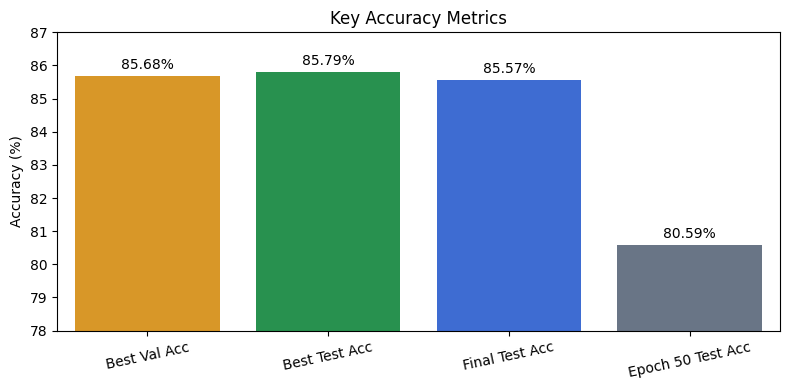

In [10]:
# 绘制关键准确率指标柱状图
metrics = pd.DataFrame({
    'metric': ['Best Val Acc', 'Best Test Acc', 'Final Test Acc', 'Epoch 50 Test Acc'],
    'accuracy': [
        best_val['val_acc'] * 100,
        best_test['test_acc'] * 100,
        final['test_acc'] * 100,
        log_df.loc[log_df['epoch'].eq(50), 'test_acc'].iloc[0] * 100,
    ],
})

plt.figure(figsize=(8, 4))
barplot = sns.barplot(data=metrics, x='metric', y='accuracy', palette=['#f59e0b', '#16a34a', '#2563eb', '#64748b'])
plt.ylim(78, 87)
plt.xlabel('')
plt.ylabel('Accuracy (%)')
plt.title('Key Accuracy Metrics')
plt.xticks(rotation=12)
for container in barplot.containers:
    barplot.bar_label(container, fmt='%.2f%%', padding=3)
plt.tight_layout()
plt.savefig(figure_dir / 'key_metrics.png', bbox_inches='tight', dpi=300)
plt.show()


In [11]:
# 选取关键 epoch 的日志记录，便于报告中引用
selected_epochs = [1, 10, 25, 50, 75, 100, 125, 131, 136, 150, 176]
selected_log = log_df[log_df['epoch'].isin(selected_epochs)].copy()
selected_log['val_acc'] = selected_log['val_acc'] * 100
selected_log['test_acc'] = selected_log['test_acc'] * 100

selected_log[['epoch', 'train_loss', 'val_loss', 'val_acc', 'test_loss', 'test_acc', 'lr']]


,epoch,train_loss,val_loss,val_acc,test_loss,test_acc,lr
0,1,1.998052,2.207528,20.36,2.207190,20.09,0.000112
9,10,1.508710,1.728305,40.58,1.722409,40.62,0.000400
24,25,1.234530,1.055048,68.34,1.050449,69.23,0.000394
49,50,1.057707,0.789346,79.58,0.774853,80.59,0.000358
74,75,0.902089,0.709243,83.36,0.697886,83.78,0.000295
99,100,0.828518,0.697774,84.58,0.684252,85.12,0.000217
124,125,0.733755,0.710751,85.32,0.703623,85.69,0.000135
130,131,0.717270,0.716786,85.46,0.710497,85.79,0.000117
135,136,0.700628,0.721611,85.68,0.715408,85.61,0.000102
149,150,0.698524,0.741339,85.42,0.732259,85.55,0.000065
